# Minimal Workflow Demonstration

In [29]:
import superstats as sup
import numpy as np

## Constants

In [2]:
NUM_STEPS = 100

## Specify an Observation Model

In [3]:
obs_model = sup.simulation.sample_ddm

## Specify a Joint Prior

Each model parameter prior can be specified via the following options:
- A `Transition` $\rightarrow$ `local_param` (time-varying, estimated)
- A `Prior` $\rightarrow$ `shared_param` (time-invariant, estimated)
- A `scalar` $\rightarrow$ `fixed_param` (time-varying, not estimated)

In [4]:
joint_prior = sup.prior.JointPrior(
    v = sup.transition.RandomWalk(
        bounds=(-6, 6),
    ),
    a = sup.transition.RandomWalk(
        bounds=(0.2, 4)
    ),
    tau = sup.prior.Prior("halfnormal", scale=0.5),
    bias = 0.5
)

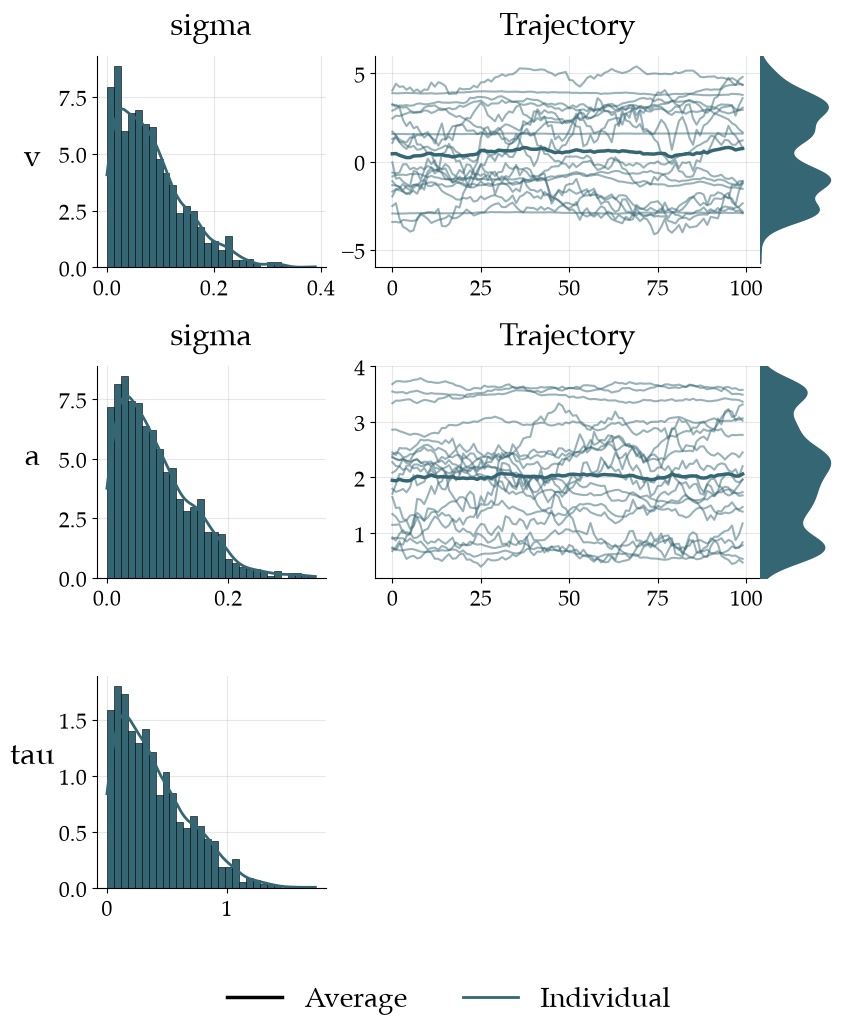

In [5]:
fig = joint_prior.plot_joint_prior(
    num_steps=NUM_STEPS,
    num_draws=1000,
    num_trajectories=20
)

## Specify a Generative Model

In [6]:
generative_model = sup.simulation.GenerativeModel(
    prior=joint_prior,
    model=obs_model,
)

In [7]:
sim_data = generative_model.sample(batch_size=10, num_steps=NUM_STEPS)

In [8]:
print(
    "Dict keys: ", sim_data.keys(), "\n",
    "Shape of response_time: ", sim_data["response_time"].shape, "\n",
    "Shape of a time-varying param: ", sim_data["v"].shape, "\n",
    "Shape of a time-invariant param: ", sim_data["v_sigma"].shape, "\n",
    sep=""
)

Dict keys: dict_keys(['response_time', 'choice', 'time_steps', 'v', 'a', 'v_sigma', 'a_sigma', 'tau'])
Shape of response_time: (10, 100)
Shape of a time-varying param: (10, 100, 1)
Shape of a time-invariant param: (10, 1)



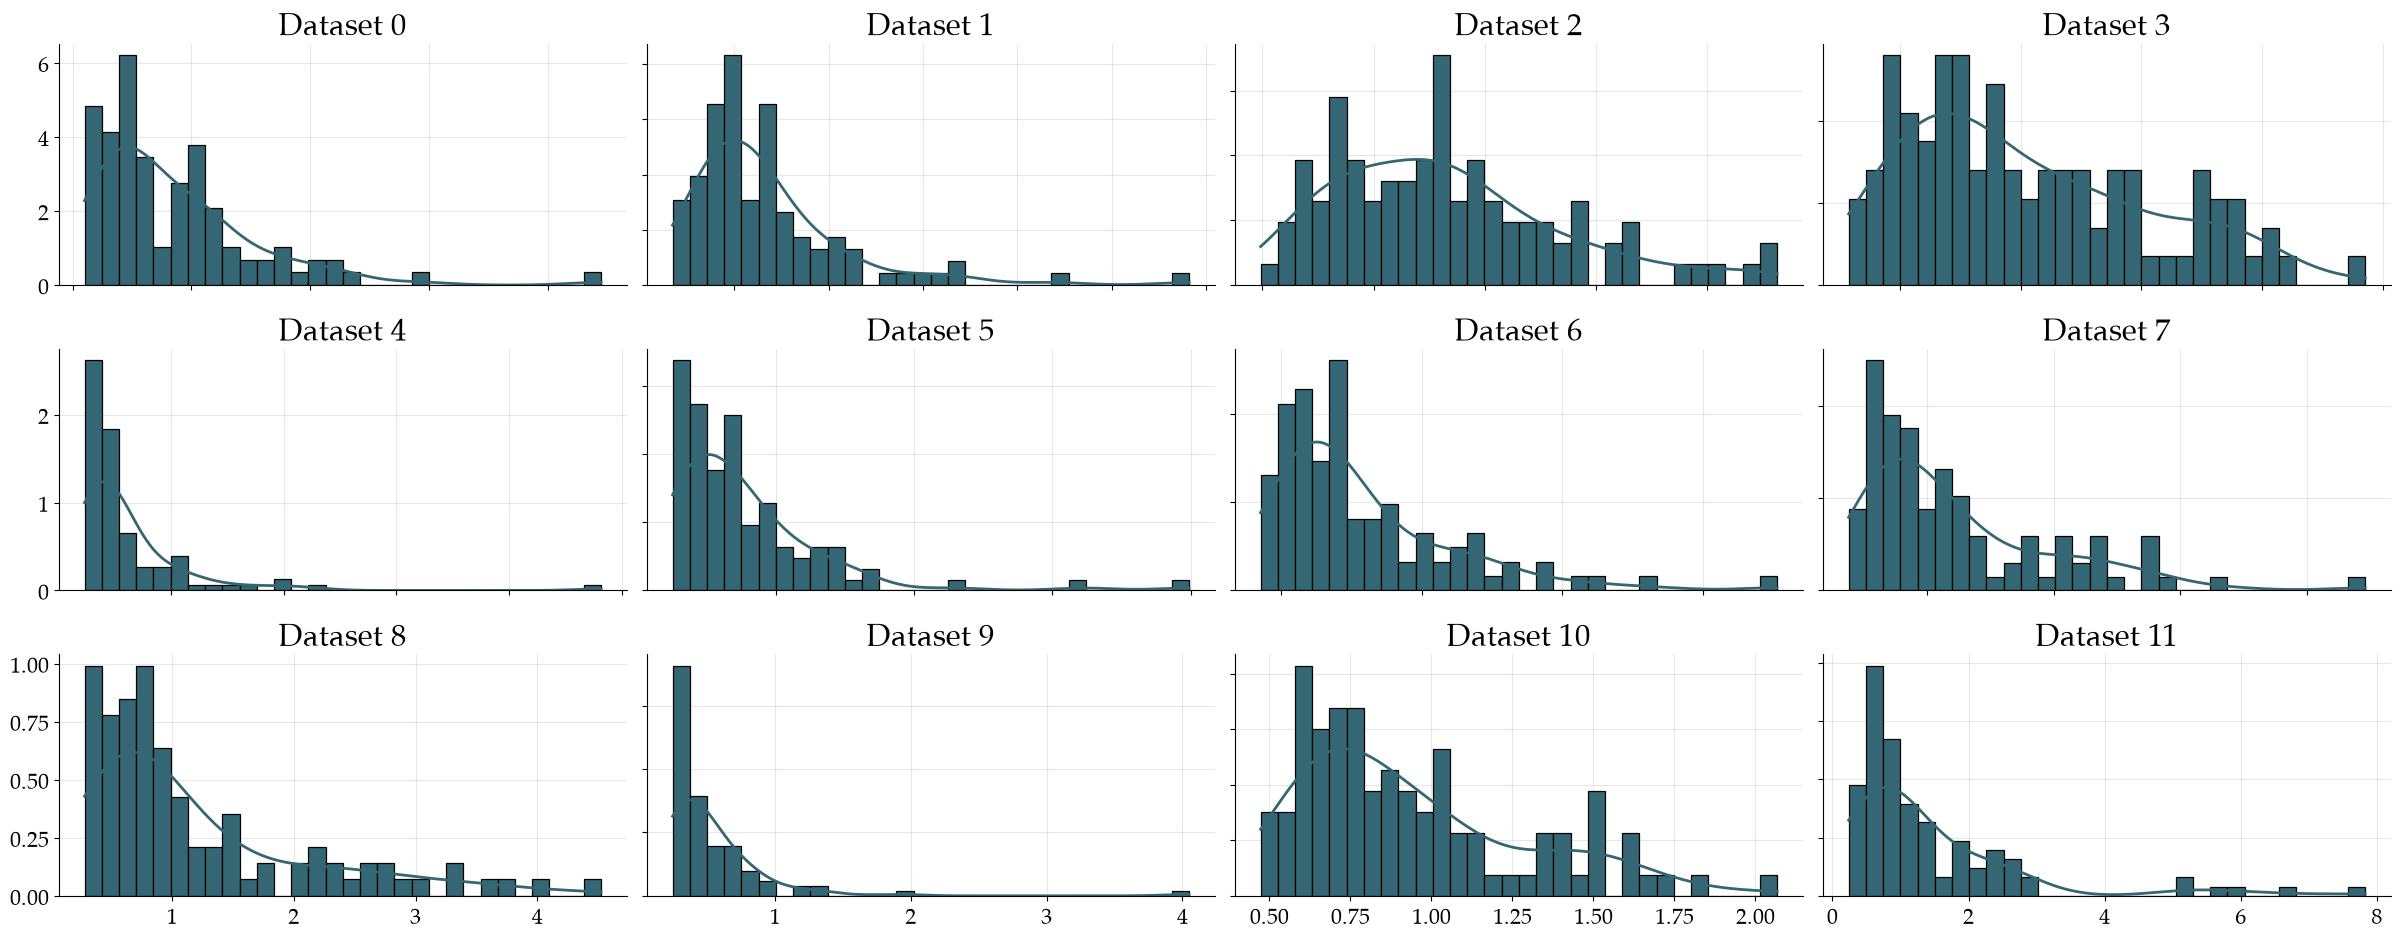

In [11]:
fig = generative_model.plot_push_forward(
    num_sim=12,
    num_steps=NUM_STEPS,
    data_dim=0,
    kind="dist",
    aggregation=None,
    num_cols=4
)

## Set up amortized Bayesian Workflow 

In [12]:
workflow = sup.workflow.Workflow(
    simulator=generative_model,
    checkpoint_filepath="checkpoints/minimal_demo",
    summary_network=sup.networks.RecurrentNet(),
    inference_network="coupling"
)

Here, users can provide summary and inference networks. Default networks are used if nothing is provided.

## Approximator Training

### Offline Training

Use offline training for fast iteration of the model develop and verification cicle

In [14]:
training_data = generative_model.sample(
    batch_size=10_000,
    num_steps=NUM_STEPS,
    tile_to_steps=True
)
val_data = generative_model.sample(
    batch_size=100,
    num_steps=NUM_STEPS,
    tile_to_steps=True
)

In [ ]:
history = workflow.fit_offline(
    data=training_data,
    validation_data=val_data,
    epochs=50,
    batch_size=32
)

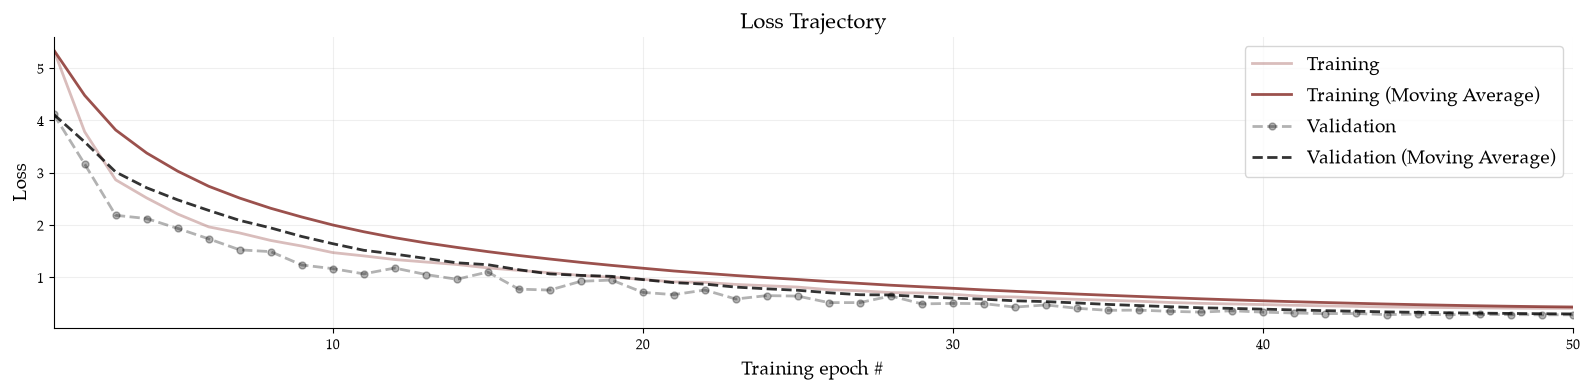

In [16]:
fig = workflow.plot_history(history)

### Online Training

Use online training for final maximal performance

In [ ]:
history = workflow.fit_online(
    num_steps=NUM_STEPS,
    epochs=50,
    num_batches_per_epoch=1000,
    batch_size=32
)

In [ ]:
fig = workflow.plot_history(history)

## Model Verification

Simulate some data for verification

In [17]:
targets = workflow.simulator.sample(
    batch_size=250,
    num_steps=NUM_STEPS,
)

Fit the model to the simulated data

In [18]:
samples = workflow.sample(
    data=targets,
    num_samples=300,
    batch_size=8
)

Summarizing:   0%|          | 0/32 [00:00<?, ?batch/s]

Sampling:   0%|          | 0/32 [00:00<?, ?batch/s]

### Time-varying Parameters

Plot four diagnostic metrics for the time-varying parameters across time:
1. Pearson correlation between true parameter and posterior median
2. Normalized root mean squared error between true parameter and posterior median
3. Posterior contraction
4. Simulation-based calibration error

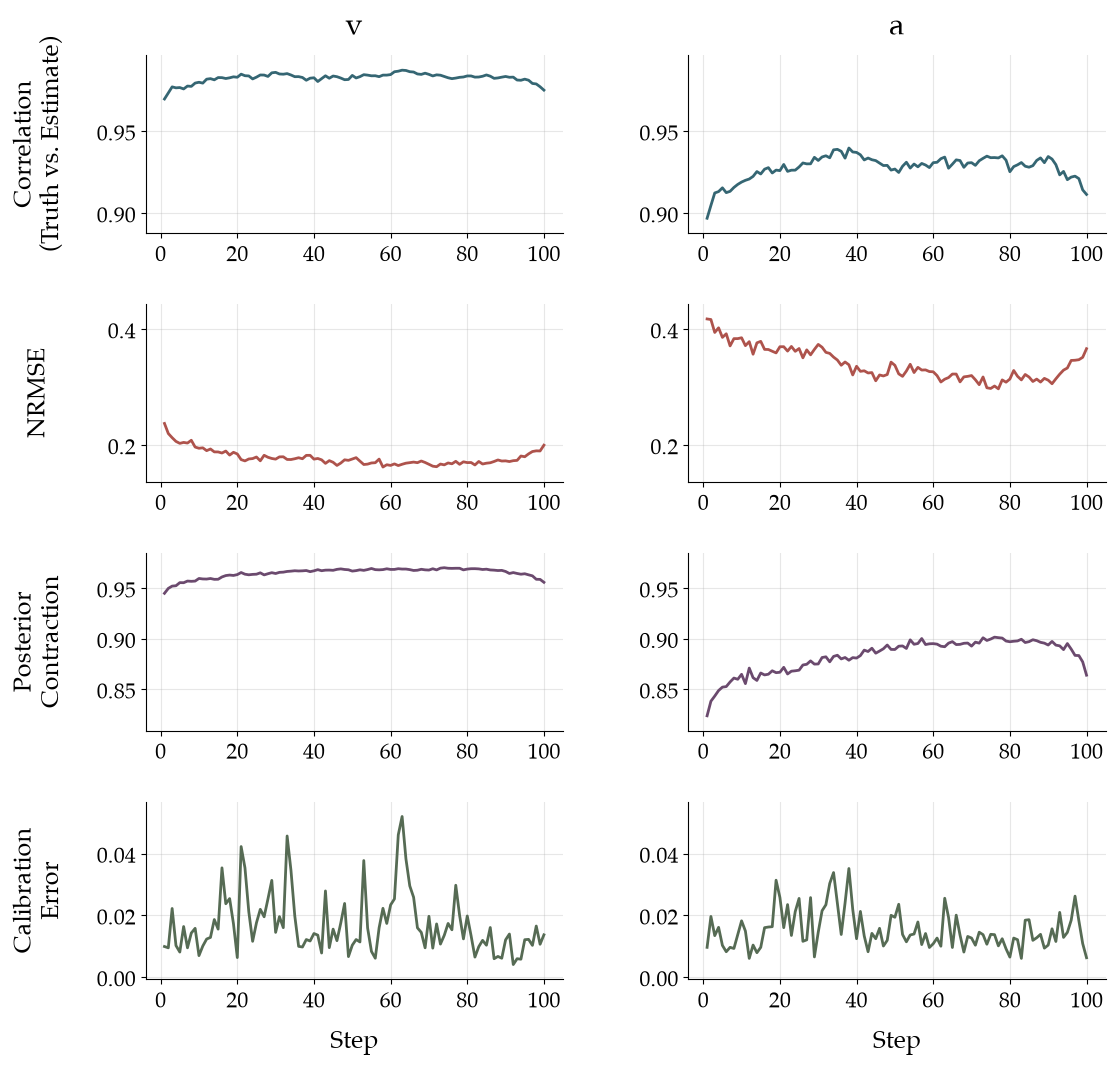

In [19]:
fig = workflow.verify_time_varying(
    targets=targets,
    estimates=samples
)

### Time-invariant Parameters

Plot recovery and simulation-based calibration for time-invariant parameters

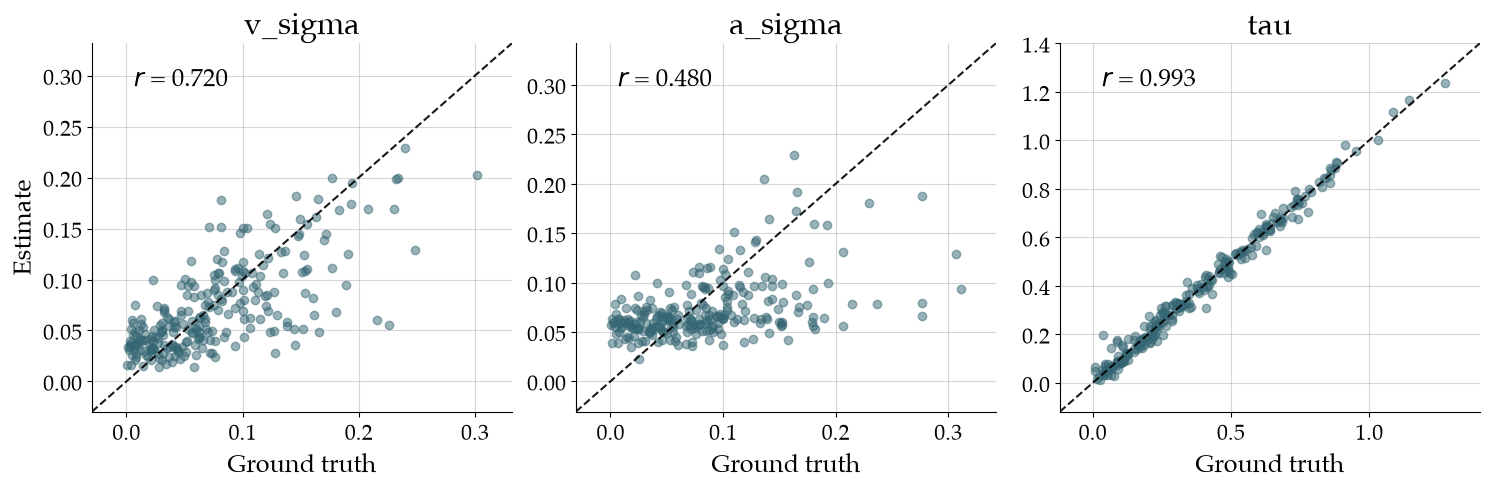

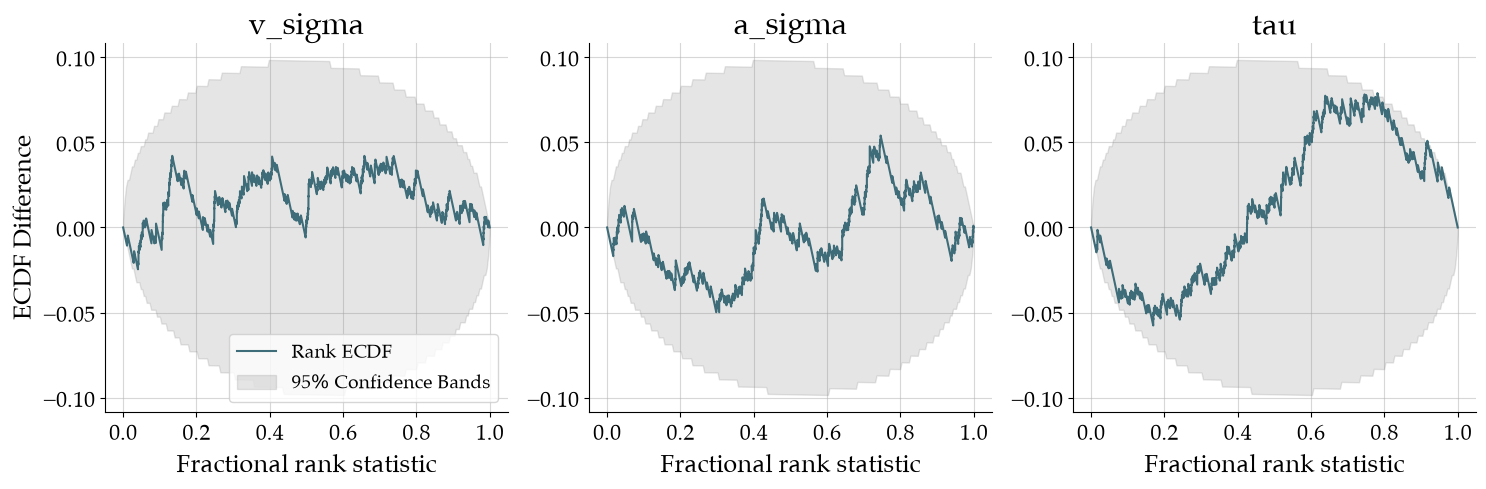

In [20]:
fig_recovery, fig_calibration = workflow.verify_time_invariant(
    estimates=samples,
    targets=targets,
    uncertainty_agg=None
)

## Fit Data

Here we could use real data and just bring it into the same shape as the simulated. However, we just use simulated data here and treat it as if it was real data.

In [21]:
num_subject = 50

data = workflow.simulator.sample(
    batch_size=num_subject,
    num_steps=NUM_STEPS
)

In [22]:
samples = workflow.sample(
    data=data,
    num_samples=500
)

Summarizing:   0%|          | 0/13 [00:00<?, ?batch/s]

Sampling:   0%|          | 0/13 [00:00<?, ?batch/s]

## Posterior Re-simulation

In [30]:
resim_data = workflow.resimulate_posterior(
    samples,
    num_sims=5
)

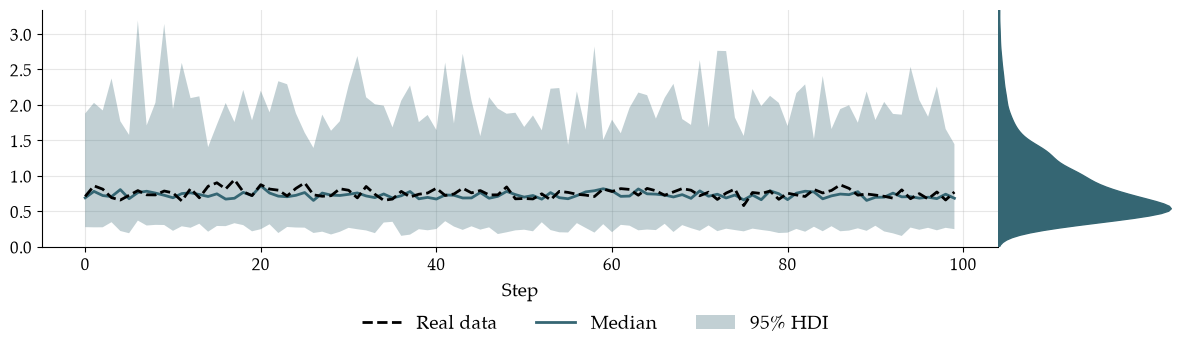

In [ ]:
fig = sup.diagnostics.plot_posterior_resimulation(
    pred_data=resim_data,
    real_data=data,
    aggregation=np.median,
    aggregate_strategy="no_epistemic",
)

## Posterior Estimates

## Time-varying

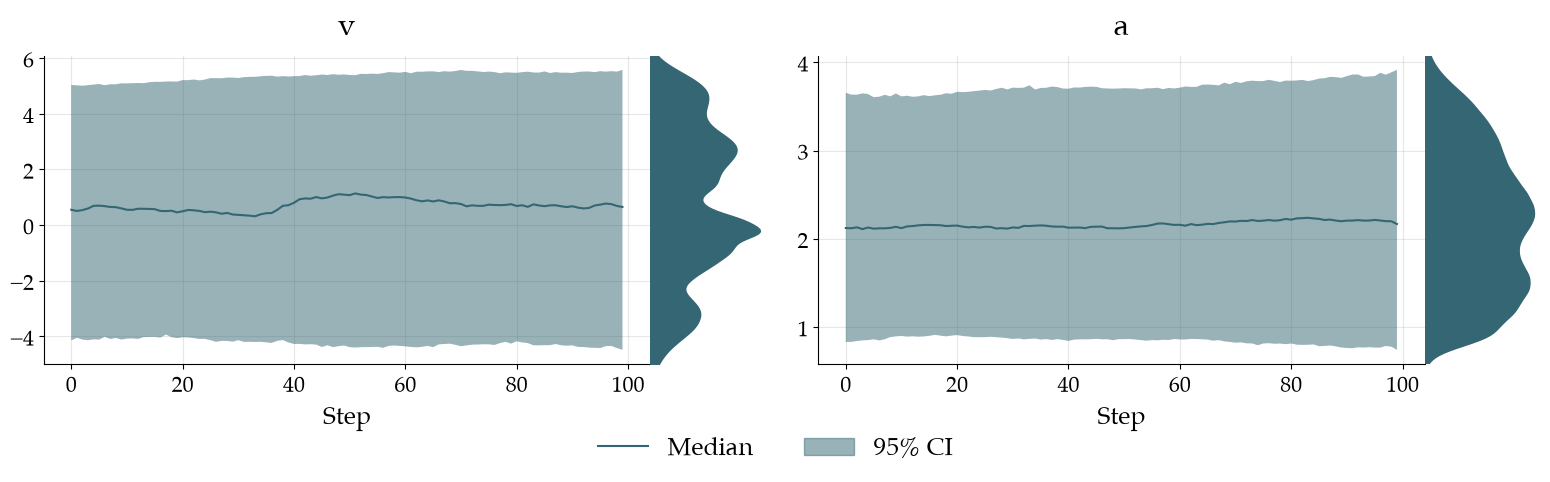

In [36]:
fig = workflow.plot_time_varying_posterior(
    estimates=samples,
    aggregation=np.median
)

## Time-invariant

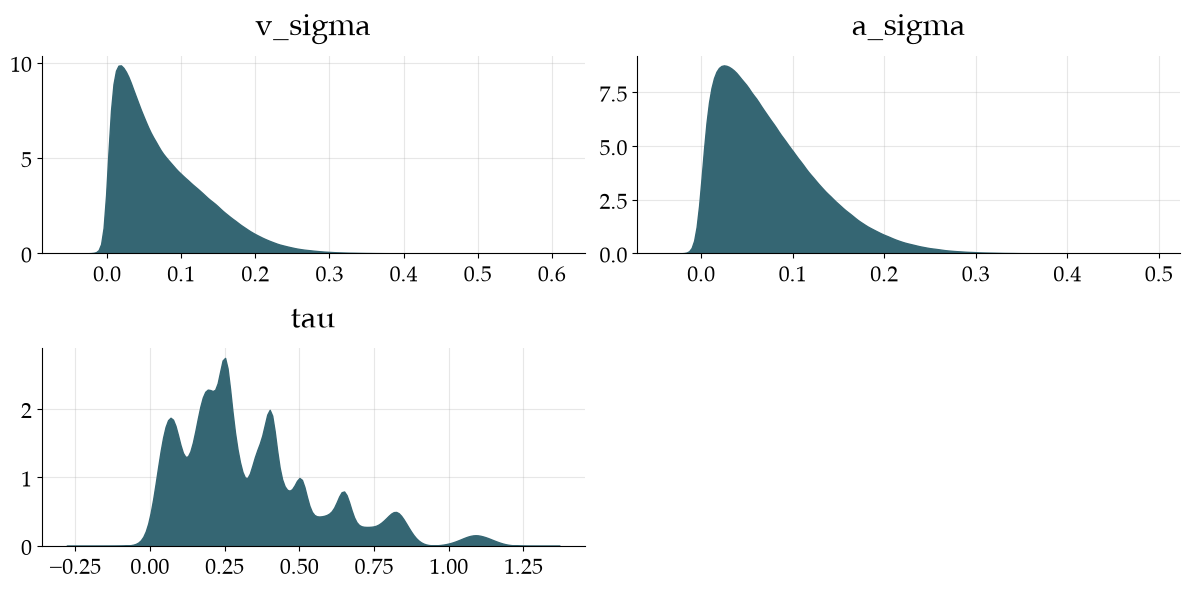

In [37]:
fig = workflow.plot_time_invariant_posterior(
    estimates=samples,
    aggregation=np.median
)